<a href="https://colab.research.google.com/github/rameelarustam47/-Assessment-of-KNN-and-Random-Forest-for-Imputing-Missing-Canal-Discharge-Data-/blob/main/last_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost tensorflow scikit-learn pandas matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
daily_csv = """Date,TempMax,Humidity
2026-08-03,33.0,71.0
2026-08-04,33.0,72.0
2026-08-05,36.5,68.33
2026-08-06,36.0,66.33
2026-08-07,34.0,56.0
2026-08-08,34.0,70.67
2026-08-09,33.5,70.67
2026-08-10,37.0,68.0
2026-08-11,36.0,75.0
2026-08-12,36.0,67.0
2026-08-13,35.0,75.67
2026-08-14,34.0,80.33
2026-08-15,36.0,73.33
2026-08-16,33.0,69.33
2026-08-17,38.0,66.33
2026-08-18,37.0,70.33
2026-08-19,37.0,74.33
2026-08-20,34.0,74.33
2026-08-21,37.5,70.0
2026-08-22,39.0,66.0
2026-08-23,36.0,58.33
"""

df = pd.read_csv(StringIO(daily_csv), parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)

df.head(10)

Shape: (21, 3)


,Date,TempMax,Humidity
0,2026-08-03,33.0,71.00
1,2026-08-04,33.0,72.00
2,2026-08-05,36.5,68.33
3,2026-08-06,36.0,66.33
4,2026-08-07,34.0,56.00
5,2026-08-08,34.0,70.67
6,2026-08-09,33.5,70.67
7,2026-08-10,37.0,68.00
8,2026-08-11,36.0,75.00
9,2026-08-12,36.0,67.00


**5. Plot temperature series**

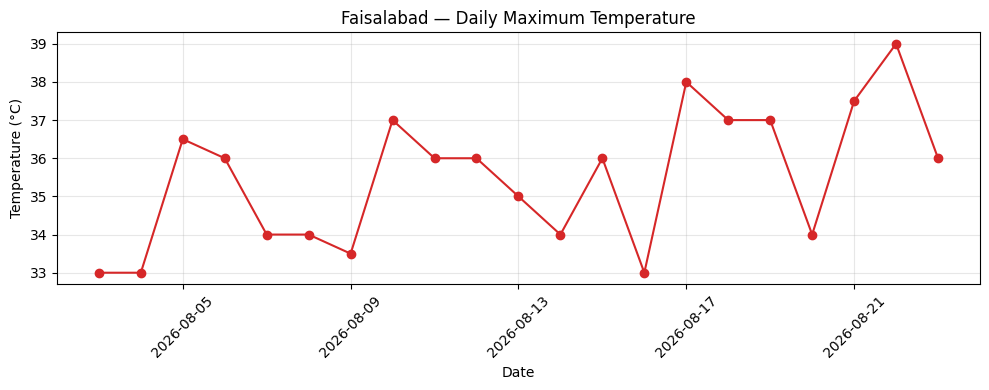

count    21.000000
mean     35.500000
std       1.781853
min      33.000000
25%      34.000000
50%      36.000000
75%      37.000000
max      39.000000
Name: TempMax, dtype: float64


In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    df["Date"],
    df["TempMax"],
    marker="o",
    color="tab:red"
)

plt.title("Faisalabad — Daily Maximum Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print(df["TempMax"].describe())

**6. Create forecasting target**

In [ ]:
df["Target"] = df["TempMax"].shift(-1)

df_model = df.dropna(
    subset=["Target"]
).reset_index(drop=True)

print(df_model.shape)

df_model.head()

(20, 4)


,Date,TempMax,Humidity,Target
0,2026-08-03,33.0,71.00,33.0
1,2026-08-04,33.0,72.00,36.5
2,2026-08-05,36.5,68.33,36.0
3,2026-08-06,36.0,66.33,34.0
4,2026-08-07,34.0,56.00,34.0


**7. XGBoost feature engineering**

In [ ]:
feat = df_model.copy()

feat["lag1"] = feat["TempMax"].shift(1)
feat["lag2"] = feat["TempMax"].shift(2)
feat["lag3"] = feat["TempMax"].shift(3)

feat["rolling3"] = (
    feat["TempMax"]
    .shift(1)
    .rolling(3)
    .mean()
)

feat = feat.dropna().reset_index(drop=True)

feature_cols = [
    "TempMax",
    "Humidity",
    "lag1",
    "lag2",
    "lag3",
    "rolling3"
]

X = feat[feature_cols]
y = feat["Target"]

print("Usable rows after lag features:", X.shape)

feat.head()

Usable rows after lag features: (17, 6)


,Date,TempMax,Humidity,Target,lag1,lag2,lag3,rolling3
0,2026-08-06,36.0,66.33,34.0,36.5,33.0,33.0,34.166667
1,2026-08-07,34.0,56.00,34.0,36.0,36.5,33.0,35.166667
2,2026-08-08,34.0,70.67,33.5,34.0,36.0,36.5,35.500000
3,2026-08-09,33.5,70.67,37.0,34.0,34.0,36.0,34.666667
4,2026-08-10,37.0,68.00,36.0,33.5,34.0,34.0,33.833333


**8. Train / validation / test split**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=False
)

print(
    "Train:", X_train.shape,
    " Val:", X_val.shape,
    " Test:", X_test.shape
)

Train: (11, 6)  Val: (3, 6)  Test: (3, 6)


**9. Train XGBoost**

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print(
    f"XGBoost  ->  "
    f"MAE: {xgb_mae:.3f}   "
    f"RMSE: {xgb_rmse:.3f}   "
    f"R2: {xgb_r2:.3f}"
)

XGBoost  ->  MAE: 3.444   RMSE: 3.723   R2: -8.241


**10. XGBoost observed vs forecast**

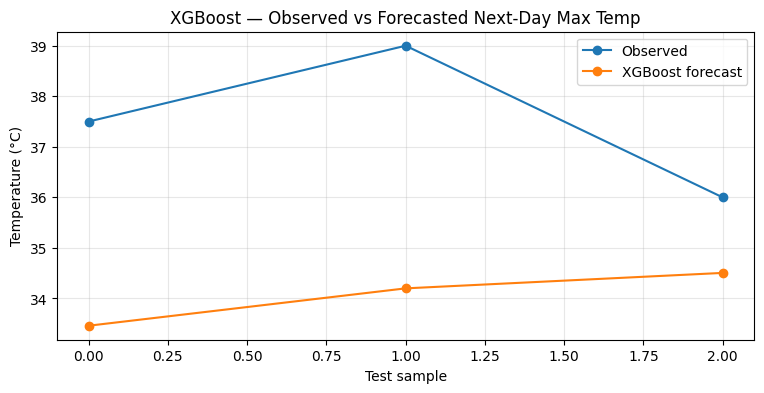

In [ ]:
plt.figure(figsize=(9, 4))

plt.plot(
    y_test.values,
    marker="o",
    label="Observed"
)

plt.plot(
    xgb_pred,
    marker="o",
    label="XGBoost forecast"
)

plt.title(
    "XGBoost — Observed vs Forecasted Next-Day Max Temp"
)

plt.xlabel("Test sample")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**11. XGBoost feature importance**

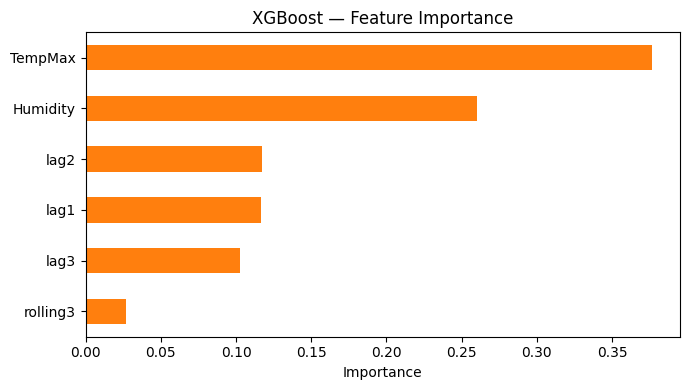

In [ ]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(7, 4))

importances.plot(
    kind="barh",
    color="tab:orange"
)

plt.title(
    "XGBoost — Feature Importance"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

**12. Prepare LSTM sequences**

In [ ]:
LOOKBACK = 5

temps = df["TempMax"].values.reshape(-1, 1)


def make_sequences(data, lookback):

    Xs = []
    ys = []

    for i in range(
        len(data) - lookback
    ):

        Xs.append(
            data[i:i + lookback]
        )

        ys.append(
            data[i + lookback]
        )

    return (
        np.array(Xs),
        np.array(ys)
    )


X_seq, y_seq = make_sequences(
    temps,
    LOOKBACK
)

print(
    "Sequence X shape:",
    X_seq.shape,
    " y shape:",
    y_seq.shape
)

Sequence X shape: (16, 5, 1)  y shape: (16, 1)


**13. LSTM train / validation / test split**

In [ ]:
n = len(X_seq)

train_end = int(n * 0.70)

val_end = int(n * 0.85)


X_train_seq = X_seq[:train_end]

y_train_seq = y_seq[:train_end]


X_val_seq = X_seq[
    train_end:val_end
]

y_val_seq = y_seq[
    train_end:val_end
]


X_test_seq = X_seq[
    val_end:
]

y_test_seq = y_seq[
    val_end:
]


print(
    "Train:",
    X_train_seq.shape,

    " Val:",
    X_val_seq.shape,

    " Test:",
    X_test_seq.shape
)

Train: (11, 5, 1)  Val: (2, 5, 1)  Test: (3, 5, 1)


**14. Scale LSTM data**

In [ ]:
scaler = StandardScaler()

scaler.fit(
    y_train_seq.reshape(-1, 1)
)


def scale_seq(X):

    shape = X.shape

    flat = X.reshape(-1, 1)

    scaled = scaler.transform(flat)

    return scaled.reshape(shape)


X_train_scaled = scale_seq(
    X_train_seq
)

X_val_scaled = scale_seq(
    X_val_seq
)

X_test_scaled = scale_seq(
    X_test_seq
)


y_train_scaled = scaler.transform(
    y_train_seq.reshape(-1, 1)
)

y_val_scaled = scaler.transform(
    y_val_seq.reshape(-1, 1)
)

y_test_scaled = scaler.transform(
    y_test_seq.reshape(-1, 1)
)

**15. Build and train LSTM**

In [ ]:
lstm_model = Sequential([
    LSTM(
        32,
        input_shape=(LOOKBACK, 1)
    ),

    Dropout(0.2),

    Dense(1)
])


lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


history = lstm_model.fit(
    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=100,

    batch_size=4,

    callbacks=[early_stop],

    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 493ms/step - loss: 1.0378 - val_loss: 1.0005
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 1.0196 - val_loss: 0.9938
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.0176 - val_loss: 0.9882
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.0004 - val_loss: 0.9831
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.0176 - val_loss: 0.9779
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0352 - val_loss: 0.9729
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.0675 - val_loss: 0.9678
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.9968 - val_loss: 0.9631
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1.0048 - val_loss: 0.9584
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.0269 - val_loss: 0.9537
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.0297 - val_loss: 0.9493
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.0128 - val_

**16. LSTM loss curve**

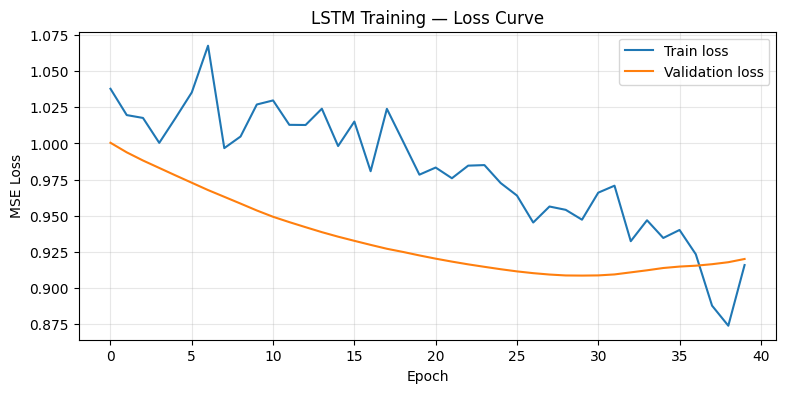

In [ ]:
plt.figure(figsize=(9, 4))

plt.plot(
    history.history["loss"],
    label="Train loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.title(
    "LSTM Training — Loss Curve"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**17. Evaluate LSTM**

In [ ]:
lstm_pred_scaled = lstm_model.predict(
    X_test_scaled
)

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

y_test_actual = y_test_seq.flatten()


lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_pred
)


print(
    f"LSTM  ->  "
    f"MAE: {lstm_mae:.3f}   "
    f"RMSE: {lstm_rmse:.3f}   "
    f"R2: {lstm_r2:.3f}"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
LSTM  ->  MAE: 2.070   RMSE: 2.411   R2: -2.876


**18. LSTM observed vs forecast**

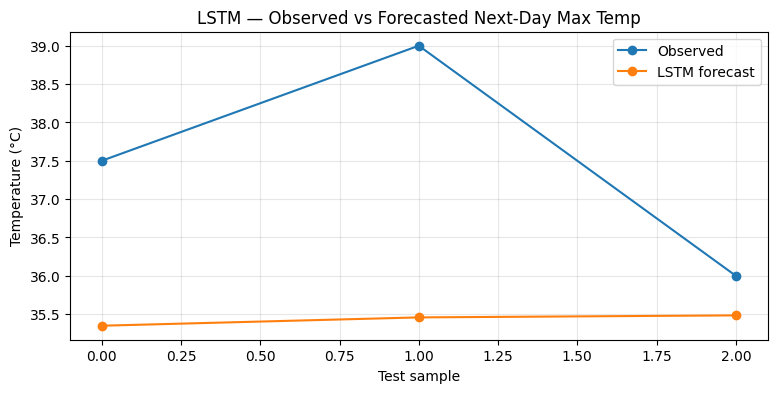

In [ ]:
plt.figure(figsize=(9, 4))

plt.plot(
    y_test_actual,
    marker="o",
    label="Observed"
)

plt.plot(
    lstm_pred,
    marker="o",
    label="LSTM forecast"
)

plt.title(
    "LSTM — Observed vs Forecasted Next-Day Max Temp"
)

plt.xlabel("Test sample")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()



19. XGBoost vs LSTM comparison


In [ ]:
comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],

    "XGBoost": [
        round(xgb_mae, 3),
        round(xgb_rmse, 3),
        round(xgb_r2, 3)
    ],

    "LSTM": [
        round(lstm_mae, 3),
        round(lstm_rmse, 3),
        round(lstm_r2, 3)
    ]
})

comparison

,Metric,XGBoost,LSTM
0,MAE,3.444,2.070
1,RMSE,3.723,2.411
2,R2,-8.241,-2.876


**20. Comparison graph**

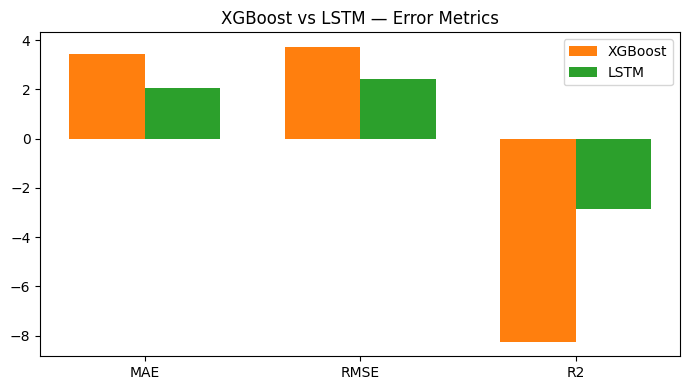

In [ ]:
fig, ax = plt.subplots(
    figsize=(7, 4)
)

x = np.arange(3)

width = 0.35


ax.bar(
    x - width / 2,
    comparison["XGBoost"],
    width,
    label="XGBoost",
    color="tab:orange"
)

ax.bar(
    x + width / 2,
    comparison["LSTM"],
    width,
    label="LSTM",
    color="tab:green"
)


ax.set_xticks(x)

ax.set_xticklabels(
    comparison["Metric"]
)

ax.set_title(
    "XGBoost vs LSTM — Error Metrics"
)

ax.legend()

plt.tight_layout()

plt.show()

**21. Forecast August 24 with XGBoost**

In [ ]:
last_row = feat.iloc[[-1]]

last_temps = df["TempMax"].values[-3:]


next_features = pd.DataFrame({

    "TempMax": [
        df["TempMax"].values[-1]
    ],

    "Humidity": [
        df["Humidity"].values[-1]
    ],

    "lag1": [
        df["TempMax"].values[-1]
    ],

    "lag2": [
        df["TempMax"].values[-2]
    ],

    "lag3": [
        df["TempMax"].values[-3]
    ],

    "rolling3": [
        np.mean(
            df["TempMax"].values[-3:]
        )
    ]

})[feature_cols]


xgb_next = xgb_model.predict(
    next_features
)[0]


print(
    f"XGBoost forecast for Aug 24: "
    f"{xgb_next:.2f} °C"
)

XGBoost forecast for Aug 24: 33.66 °C


**22. Forecast August 24 with LSTM**

In [ ]:
last_window = (
    df["TempMax"]
    .values[-LOOKBACK:]
    .reshape(1, LOOKBACK, 1)
)


last_window_scaled = scale_seq(
    last_window
)


lstm_next_scaled = lstm_model.predict(
    last_window_scaled
)


lstm_next = scaler.inverse_transform(
    lstm_next_scaled
)[0][0]


print(
    f"LSTM forecast for Aug 24: "
    f"{lstm_next:.2f} °C"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
LSTM forecast for Aug 24: 35.36 °C
